In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv')
df.head()

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1


### Data Prep

- Check if the missing values are presented in the features.
- If there are missing values:
- For categorical features, replace them with 'NA'
- For numerical features, replace with with 0.0

In [13]:
df.isna().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [18]:
df.dtypes

lead_source                     str
industry                        str
number_of_courses_viewed      int64
annual_income               float64
employment_status               str
location                        str
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [25]:
categorical = [
    'lead_source', 'industry', 'employment_status', 'location'
]

numerical = [
    'number_of_courses_viewed', 'annual_income', 'interaction_count', 'lead_score'
]    

In [30]:
df[numerical].describe().round(1)

,number_of_courses_viewed,annual_income,interaction_count,lead_score
count,1462.0,1281.0,1462.0,1462.0
mean,2.0,59886.3,3.0,0.5
std,1.4,15070.1,1.7,0.3
min,0.0,13929.0,0.0,0.0
25%,1.0,49698.0,2.0,0.3
50%,2.0,60148.0,3.0,0.5
75%,3.0,69639.0,4.0,0.8
max,9.0,109899.0,11.0,1.0


In [32]:
df[categorical] = df[categorical].fillna('NA')
df[numerical] = df[numerical].fillna(0)
df.isna().sum()

lead_source                 0
industry                    0
number_of_courses_viewed    0
annual_income               0
employment_status           0
location                    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

### Q1

What is the mode for the column industry?

In [33]:
df[categorical].describe()

,lead_source,industry,employment_status,location
count,1462,1462,1462,1462
unique,6,8,5,8
top,organic_search,retail,self_employed,north_america
freq,282,203,352,225


*the answer is retail*

### Q2

Create the correlation matrix for the numerical features of your dataset. In a correlation matrix, you compute the correlation coefficient between every pair of features.

What are the two features that have the biggest correlation?

In [50]:
df[numerical].describe()

,number_of_courses_viewed,annual_income,interaction_count,lead_score
count,1462.000000,1462.000000,1462.000000,1462.000000
mean,2.031464,52472.172367,2.976744,0.506108
std,1.449717,24254.347030,1.681564,0.288465
min,0.000000,0.000000,0.000000,0.000000
25%,1.000000,44097.250000,2.000000,0.262500
50%,2.000000,57449.500000,3.000000,0.510000
75%,3.000000,68241.000000,4.000000,0.750000
max,9.000000,109899.000000,11.000000,1.000000


In [48]:
df.corr(numeric_only=True)

,number_of_courses_viewed,annual_income,interaction_count,lead_score,converted
number_of_courses_viewed,1.000000,0.009770,-0.023565,-0.004879,0.435914
annual_income,0.009770,1.000000,0.027036,0.015610,0.053131
interaction_count,-0.023565,0.027036,1.000000,0.009888,0.374573
lead_score,-0.004879,0.015610,0.009888,1.000000,0.193673
converted,0.435914,0.053131,0.374573,0.193673,1.000000


In [47]:
df[numerical].corrwith(df.converted).sort_values(ascending=False)

number_of_courses_viewed    0.435914
interaction_count           0.374573
lead_score                  0.193673
annual_income               0.053131
dtype: float64

*interaction_count and lead_score
number_of_courses_viewed and lead_score*

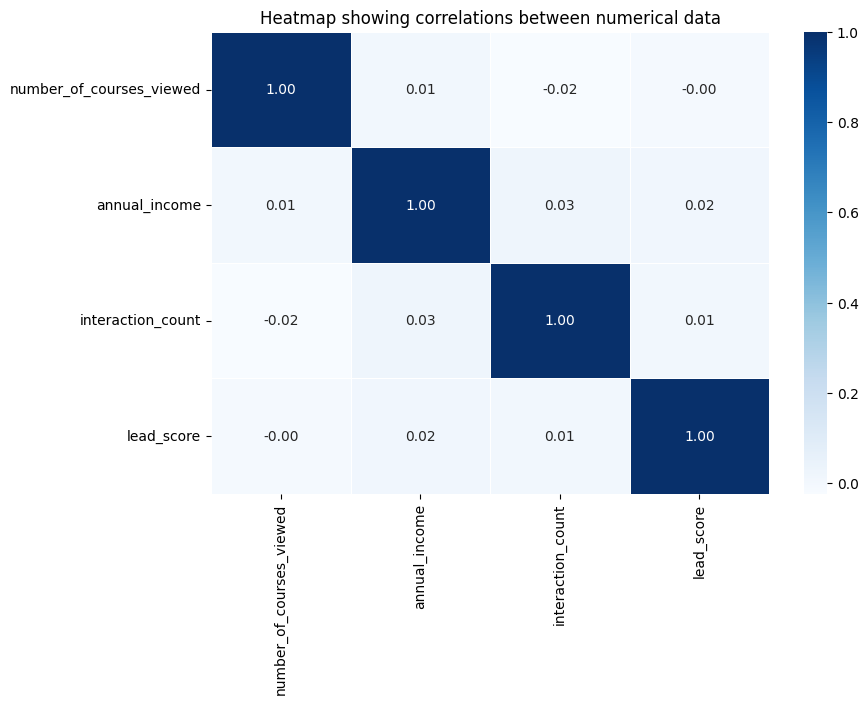

In [84]:
plt.figure(figsize=(9, 6))
sns.heatmap(df[numerical].corr(), 
            annot = True,
            cmap = "Blues",
            fmt=".2f",
            linewidths=.5
           )
plt.title('Heatmap showing correlations between numerical data')
plt.show()

In [88]:
df[numerical].corr().unstack().sort_values(ascending=False)

number_of_courses_viewed  number_of_courses_viewed    1.000000
annual_income             annual_income               1.000000
lead_score                lead_score                  1.000000
interaction_count         interaction_count           1.000000
annual_income             interaction_count           0.027036
interaction_count         annual_income               0.027036
lead_score                annual_income               0.015610
annual_income             lead_score                  0.015610
lead_score                interaction_count           0.009888
interaction_count         lead_score                  0.009888
annual_income             number_of_courses_viewed    0.009770
number_of_courses_viewed  annual_income               0.009770
lead_score                number_of_courses_viewed   -0.004879
number_of_courses_viewed  lead_score                 -0.004879
                          interaction_count          -0.023565
interaction_count         number_of_courses_viewed   -0